<a href="https://colab.research.google.com/github/AmirMohammad73/semantic_folding/blob/main/ISOMAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
import umap
import os
import gensim.downloader as api

# Load corpus
with open("/content/drive/MyDrive/secondopenbook1.txt", "r") as file:
    corpus = file.readlines()

# Load GloVe word embeddings
glove_model = api.load("glove-wiki-gigaword-300")


[==================================================] 100.0% 376.1/376.1MB downloaded


In [ ]:

# Create document vectors using GloVe embeddings
document_vectors = []
for doc in corpus:
    doc_vector = []
    for word in doc.split():
        if word in glove_model:
            doc_vector.append(glove_model[word])
    if doc_vector:
        document_vectors.append(np.mean(doc_vector, axis=0))
    else:
        document_vectors.append(np.zeros(300))

# Dimensionality reduction
n_components = 300
svd = TruncatedSVD(n_components=n_components)
document_vectors_reduced = svd.fit_transform(document_vectors)

# Clustering with UMAP
umap_model = umap.UMAP(n_components=2, random_state=123)  # Set a fixed random seed
document_vectors_umap = umap_model.fit_transform(document_vectors_reduced)


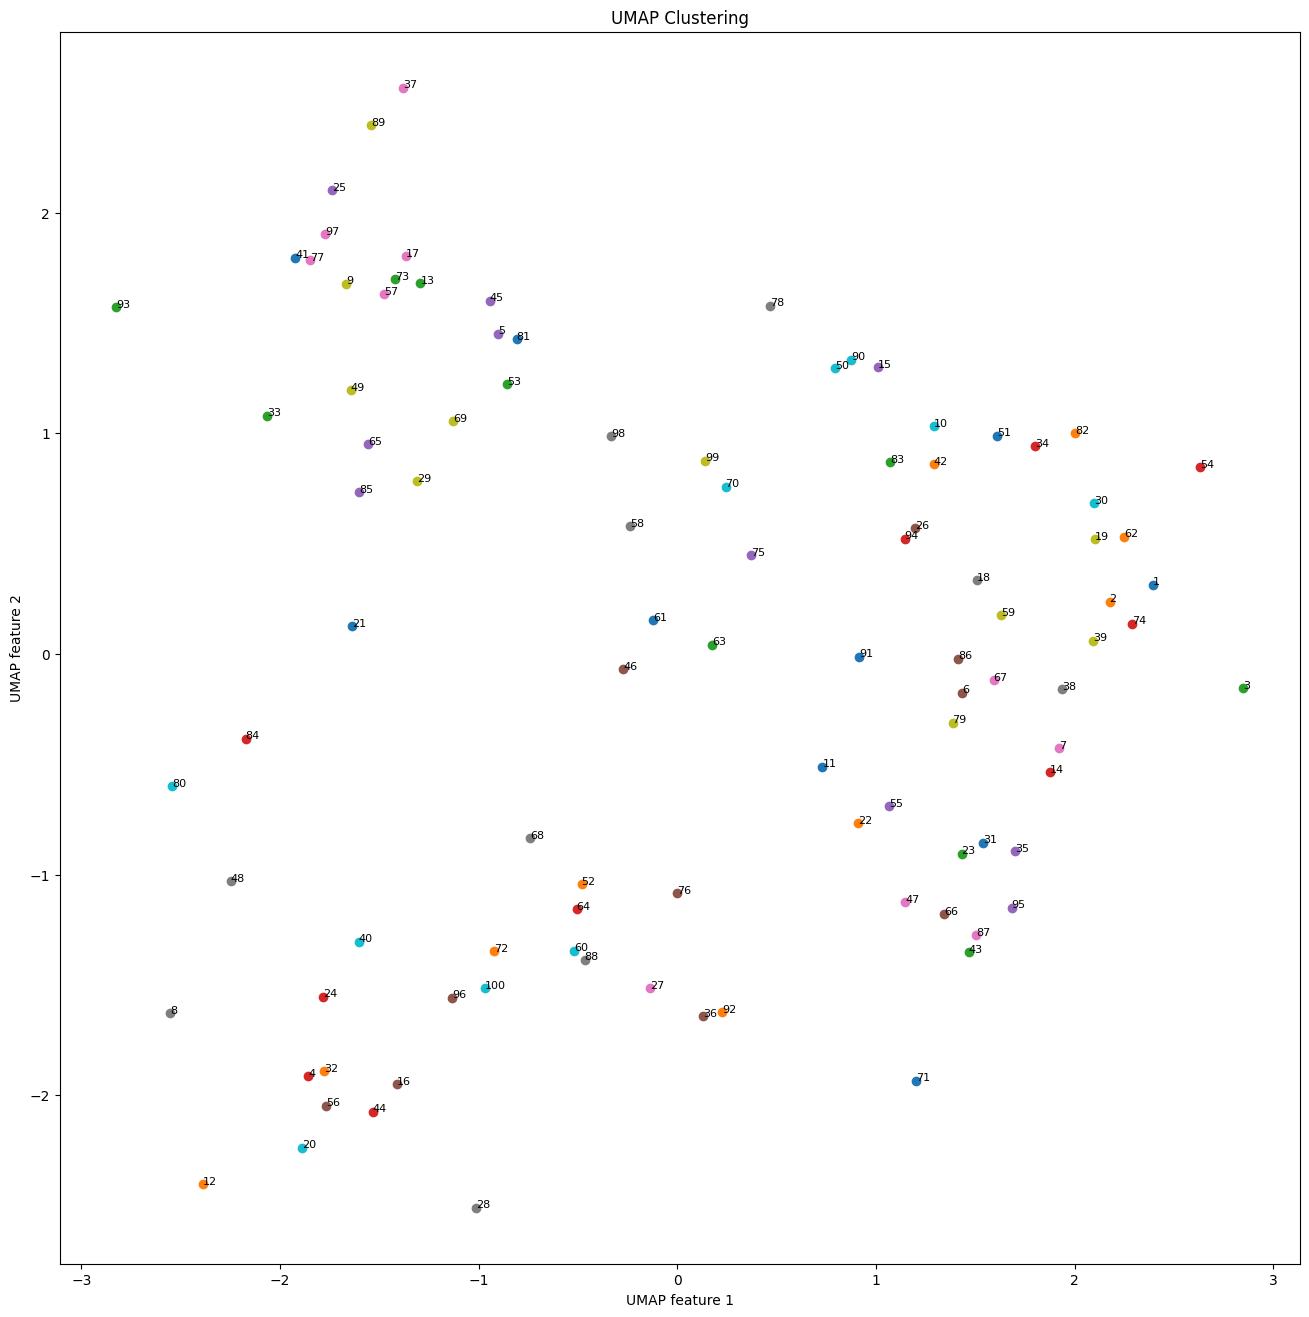

In [ ]:
# Plot UMAP clusters
plt.figure(figsize=(16, 16))
for i, (x, y) in enumerate(document_vectors_isomap):
    document_id = i + 1
    plt.scatter(x, y)
    plt.annotate(str(document_id), (x, y), fontsize=8)  # Adjust the fontsize parameter
plt.xlabel('UMAP feature 1')
plt.ylabel('UMAP feature 2')
plt.title('UMAP Clustering')
plt.show()

In [ ]:
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
!pip install trimap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for annoy: filename=annoy-1.17.3-cp310-cp310-linux_x86_64.whl size=552450 sha256=82fdf8140da8c6c8f7893606e11ae03ce632d979dd7c3ddfa8ab0a545ef5da91
  Stored in directory: /root/.cache/pip/wheels/64/8a/da/f714bcf46c5efdcfcac0559e63370c21abe961c48e3992465a
Successfully built annoy


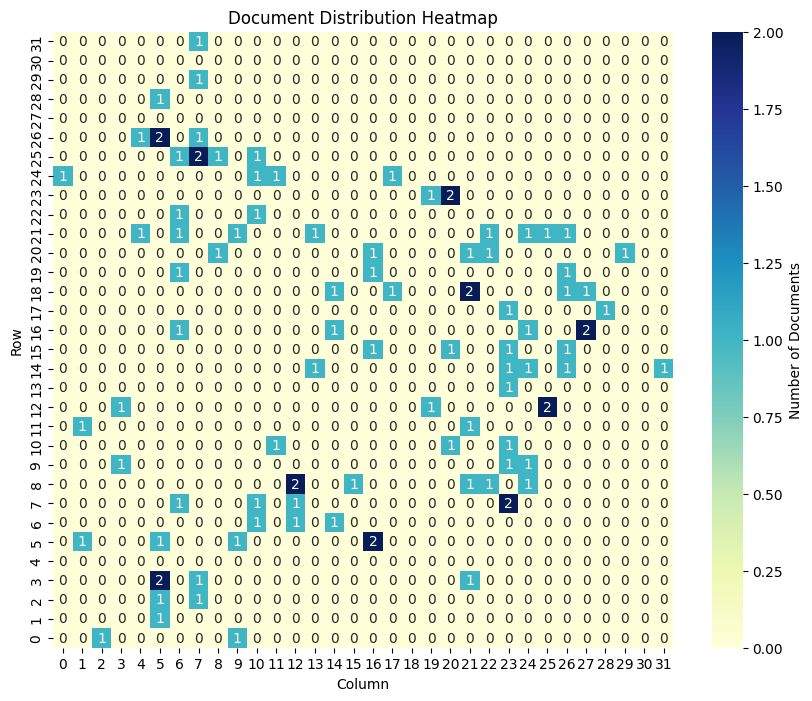

In [ ]:
from nltk.corpus import wordnet
import spacy
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import Isomap
import json
import seaborn as sns
# Load spaCy's English model
nlp = spacy.load("en_core_web_sm")

def standardize_synonyms(text):
    words = text.split()
    standardized_words = []
    for word in words:
        synsets = wordnet.synsets(word)
        if synsets:
            standardized_word = synsets[0].lemmas()[0].name()
            standardized_words.append(standardized_word)
        else:
            standardized_words.append(word)
    return " ".join(standardized_words)

# Load corpus
with open("/content/drive/MyDrive/cleaned_raw_corpus.txt", "r") as file:
    corpus = file.readlines()

# Standardize synonyms in the corpus using spaCy lemmatization
standardized_corpus = [standardize_synonyms(context) for context in corpus]

# Create a TF-IDF vectorizer
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(standardized_corpus)

# Get the vocabulary and its indices
vocabulary = vectorizer.get_feature_names_out()

# Initialize the document vectors
num_contexts = len(standardized_corpus)
num_vocab = len(vocabulary)
document_vectors = np.zeros((num_contexts, num_vocab))

# Fill in the document vectors with TF-IDF values
for i, context in enumerate(standardized_corpus):
    context_tfidf = tfidf_matrix[i].toarray().flatten()
    document_vectors[i] = context_tfidf

# Clustering with Isomap
isomap_model = Isomap(n_components=2)  # Set a fixed random seed
document_vectors_isomap = isomap_model.fit_transform(document_vectors)

# Create a 16x16 grid
grid_size = 32
grid = np.zeros((grid_size, grid_size), dtype=int)

# Map document_ids to grid coordinates
for i, (x, y) in enumerate(document_vectors_isomap):
    document_id = i + 1
    row = int((y - document_vectors_isomap[:, 1].min()) / (document_vectors_isomap[:, 1].max() - document_vectors_isomap[:, 1].min()) * (grid_size - 1))
    col = int((x - document_vectors_isomap[:, 0].min()) / (document_vectors_isomap[:, 0].max() - document_vectors_isomap[:, 0].min()) * (grid_size - 1))
    grid[row, col] += 1

# Create a heatmap using seaborn
plt.figure(figsize=(10, 8))
ax = sns.heatmap(grid, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={"label": "Number of Documents"})
plt.xlabel('Column')
plt.ylabel('Row')
plt.title('Document Distribution Heatmap')
ax.invert_yaxis()
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np

def calculate_euclidean_distance(vector1, vector2):
    return np.linalg.norm(vector1 - vector2)

# Get the number of document vectors
max_id = len(document_vectors_isomap)
# Calculate all possible pairwise distances
distances = []
for i in range(max_id):
    for j in range(i + 1, max_id):  # Avoid redundant calculations
        vector1 = document_vectors_isomap[i]
        vector2 = document_vectors_isomap[j]
        dist = calculate_euclidean_distance(vector1, vector2)
        print(i+1, j+1, dist)


1 2 0.2304640548195535
1 3 0.6546618512321709
1 4 4.798971972522396
1 5 3.4852779408591914
1 6 1.0783816764392213
1 7 0.878053647875254
1 8 5.313187342109881
1 9 4.281771897993564
1 10 1.316035814750655
1 11 1.8558811662040238
1 12 5.4983093527884295
1 13 3.9304161550767933
1 14 0.9953275964522393
1 15 1.6967254839487926
1 16 4.4277582813880985
1 17 4.043738322731125
1 18 0.8841422808338014
1 19 0.35681970181099176
1 20 4.986227485957378
1 21 4.0347324381482235
1 22 1.8373097584273546
1 23 1.5535341564236143
1 24 4.57646551233623
1 25 4.500321950966993
1 26 1.221971601848608
1 27 3.1208080058143968
1 28 4.424459179788623
1 29 3.731914794129886
1 30 0.47239780806933657
1 31 1.4470174827637687
1 32 4.718385315899203
1 33 4.522318374772933
1 34 0.8618726244334817
1 35 1.3940334294228827
1 36 2.9911070309022256
1 37 4.395609862672974
1 38 0.6563343339597076
1 39 0.3946171030086843
1 40 4.312151075997889
1 41 4.562713669946761
1 42 1.2288669794621008
1 43 1.9056242819103948
1 44 4.595040399

In [ ]:
# Function to calculate Euclidean distance
def calculate_euclidean_distance(vector1, vector2):
    return np.linalg.norm(vector1 - vector2)

# Ask user for two IDs
id1 = int(input("Enter the first ID: "))
id2 = int(input("Enter the second ID: "))

# Check if the IDs are within the range of the document IDs
max_id = len(document_vectors_umap)
if id1 > 0 and id1 <= max_id and id2 > 0 and id2 <= max_id:
    # Get the corresponding vectors for each ID
    vector1 = document_vectors_umap[id1 - 1]
    vector2 = document_vectors_umap[id2 - 1]

    # Calculate distance
    distance = calculate_euclidean_distance(vector1, vector2)
    print(f"The Euclidean distance between ID {id1} and ID {id2} is: {distance}")
else:
    print("One of the input IDs is out of range. Please enter a valid document ID between 1 and", max_id)


Enter the first ID: 12
Enter the second ID: 15
The Euclidean distance between ID 12 and ID 15 is: 3.2793686389923096
